<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_csv("Mall_Customers.csv")


In [3]:
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape


(200, 5)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.isnull().sum()


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
df = df.dropna()


In [9]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric.head()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


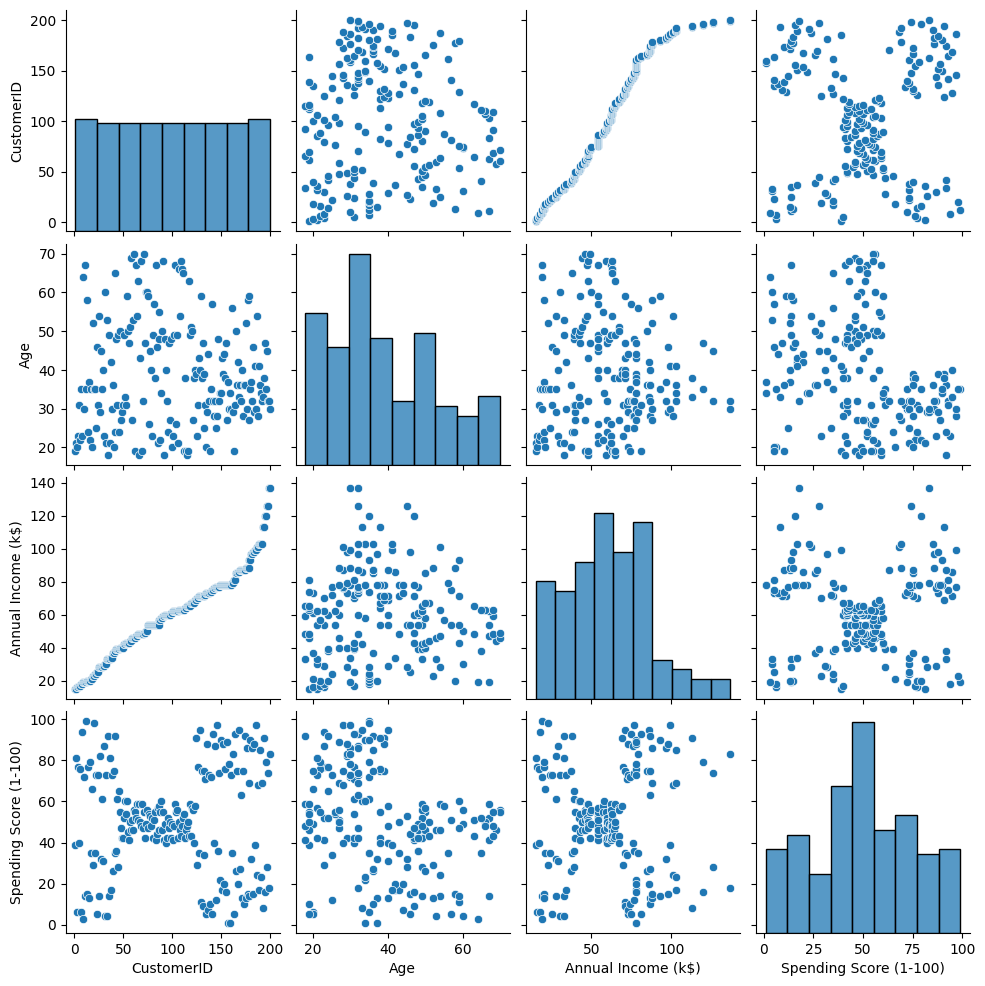

In [10]:
sns.pairplot(df_numeric)
plt.show()


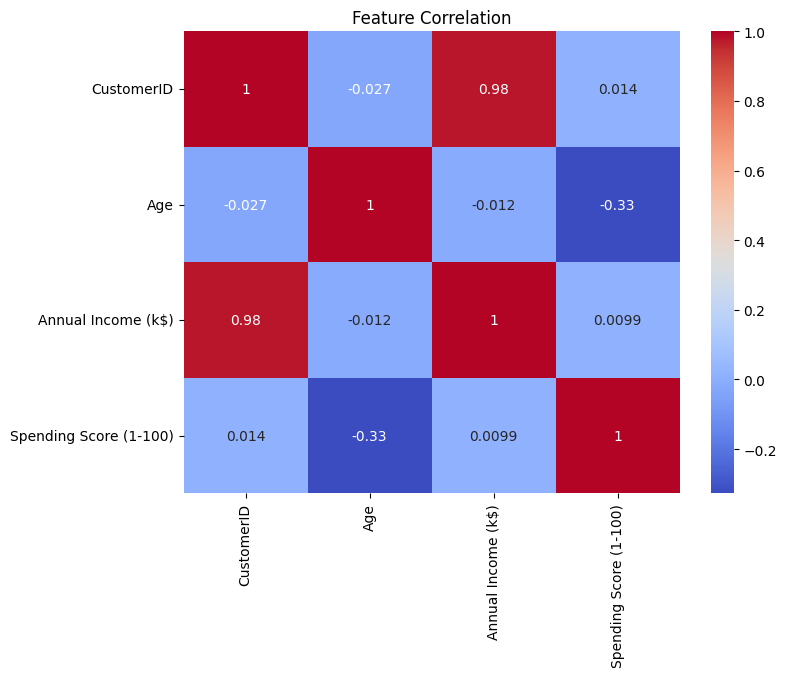

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)


In [13]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)


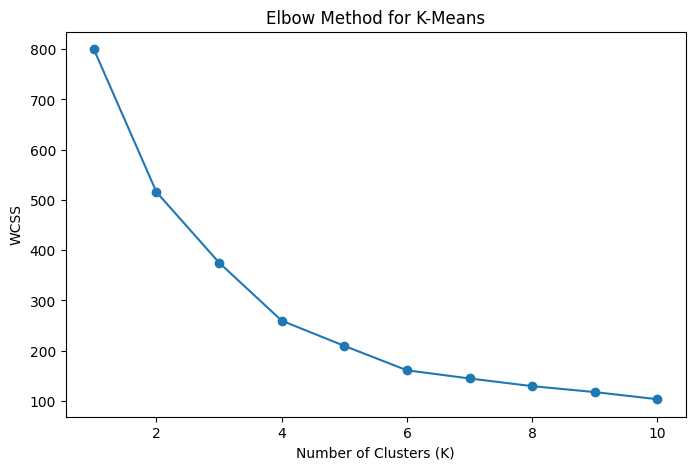

In [14]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for K-Means")
plt.show()


In [15]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)


In [16]:
kmeans.fit(scaled_data)


KMeans(n_clusters=3, n_init=10, random_state=42)

In [17]:
clusters = kmeans.predict(scaled_data)


In [18]:
df['Cluster'] = clusters
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


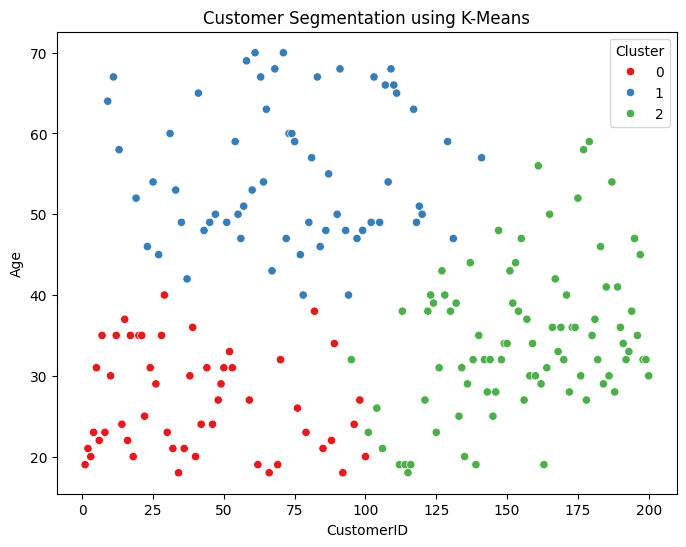

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_numeric.iloc[:,0],
    y=df_numeric.iloc[:,1],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title("Customer Segmentation using K-Means")
plt.show()


In [20]:
sil_score = silhouette_score(scaled_data, clusters)
sil_score


np.float64(0.33627250175154105)

In [21]:
df.groupby('Cluster').mean(numeric_only=True)


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,41.384615,26.807692,34.884615,59.211538
1,73.112903,54.983871,49.419355,40.338710
2,155.988372,34.500000,84.116279,51.860465


In [22]:
pd.crosstab(df['Cluster'], df['Gender'])


Gender,Female,Male
Cluster,,
0,31,21
1,34,28
2,47,39


In [23]:
kmeans.cluster_centers_


array([[-1.0239213 , -0.86423656, -0.98001477,  0.34984199],
       [-0.47436436,  1.15787451, -0.42523207, -0.38283068],
       [ 0.96109881, -0.3121851 ,  0.89912973,  0.06446185]])

In [24]:
df.to_csv("kmeans_clustered_customers.csv", index=False)
